In [170]:
import pandas as pd

In [171]:
movies = pd.read_csv("../data/raw/tmdb_5000_movies.csv").rename(
    columns={"original_title": "title"}
)

In [172]:
raw_movies = pd.read_csv("../data/raw/tmdb_5000_movies.csv")

In [173]:
raw_movies.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')

In [174]:
movies_processed = pd.read_csv(
    "../data/processed/processed_movies.csv"
)

movies_processed.columns

Index(['id', 'title', 'title.1', 'tags', 'cluster', 'component_1',
       'component_2'],
      dtype='object')

In [175]:
metadata = raw_movies[
    ["id", "overview", "genres", "keywords"]
].copy()

In [176]:
movies = movies_processed.merge(
    metadata,
    on="id",
    how="left"
)

movies = movies.reset_index(drop=True)

In [177]:
raw_movies[["id", "title", "overview", "genres"]].head()

,id,title,overview,genres
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."


In [178]:
movies[movies["title"] == "Avengers: Age of Ultron"][
    ["id", "title", "overview", "genres"]
]

,id,title,overview,genres
7,99861,Avengers: Age of Ultron,When Tony Stark tries to jumpstart a dormant p...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."


In [179]:
movies.head()

,id,title,title.1,tags,cluster,component_1,component_2,overview,genres,keywords
0,19995,Avatar,Avatar,action adventure fantasy sciencefiction cultur...,2,0.114856,0.115005,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":..."
1,285,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End,adventure fantasy action ocean drugabuse exoti...,2,0.100995,0.050272,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na..."
2,206647,Spectre,Spectre,action adventure crime spy basedonnovel secret...,2,0.103555,0.119302,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name..."
3,49026,The Dark Knight Rises,The Dark Knight Rises,action crime drama thriller dccomics crimefigh...,4,0.111033,0.100697,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,..."
4,49529,John Carter,John Carter,action adventure sciencefiction basedonnovel m...,2,0.112880,0.127372,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":..."


In [180]:
movies[movies["title"] == "Captain America: Civil War"][
    ["id", "title", "overview", "genres"]
]

,id,title,overview,genres
26,271110,Captain America: Civil War,"Following the events of Age of Ultron, the col...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""..."


In [181]:
movies.shape

(4803, 10)

In [182]:
movies.columns

Index(['id', 'title', 'title.1', 'tags', 'cluster', 'component_1',
       'component_2', 'overview', 'genres', 'keywords'],
      dtype='object')

In [183]:
credits = pd.read_csv("../data/raw/tmdb_5000_credits.csv")

In [184]:
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [185]:
credits.shape

(4803, 4)

In [186]:
credits.columns

Index(['movie_id', 'title', 'cast', 'crew'], dtype='object')

In [187]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           4803 non-null   int64  
 1   title        4803 non-null   object 
 2   title.1      4803 non-null   object 
 3   tags         4803 non-null   object 
 4   cluster      4803 non-null   int64  
 5   component_1  4803 non-null   float64
 6   component_2  4803 non-null   float64
 7   overview     4800 non-null   object 
 8   genres       4803 non-null   object 
 9   keywords     4803 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 375.4+ KB


In [188]:
movies.isnull().sum()

id             0
title          0
title.1        0
tags           0
cluster        0
component_1    0
component_2    0
overview       3
genres         0
keywords       0
dtype: int64

In [189]:
movies.duplicated().sum()

np.int64(0)

In [190]:
movies["id"].duplicated().sum()

np.int64(0)

In [191]:
movies.iloc[0]

id                                                         19995
title                                                     Avatar
title.1                                                   Avatar
tags           action adventure fantasy sciencefiction cultur...
cluster                                                        2
component_1                                             0.114856
component_2                                             0.115005
overview       In the 22nd century, a paraplegic Marine is di...
genres         [{"id": 28, "name": "Action"}, {"id": 12, "nam...
keywords       [{"id": 1463, "name": "culture clash"}, {"id":...
Name: 0, dtype: object

In [192]:
movies.loc[0, "genres"]

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [193]:
movies.loc[0, "keywords"]

'[{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386, "name": "space war"}, {"id": 3388, "name": "space colony"}, {"id": 3679, "name": "society"}, {"id": 3801, "name": "space travel"}, {"id": 9685, "name": "futuristic"}, {"id": 9840, "name": "romance"}, {"id": 9882, "name": "space"}, {"id": 9951, "name": "alien"}, {"id": 10148, "name": "tribe"}, {"id": 10158, "name": "alien planet"}, {"id": 10987, "name": "cgi"}, {"id": 11399, "name": "marine"}, {"id": 13065, "name": "soldier"}, {"id": 14643, "name": "battle"}, {"id": 14720, "name": "love affair"}, {"id": 165431, "name": "anti war"}, {"id": 193554, "name": "power relations"}, {"id": 206690, "name": "mind and soul"}, {"id": 209714, "name": "3d"}]'

In [194]:
movies.loc[0, "overview"]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [195]:
credits.loc[0, "cast"]

'[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "credit_id": "52fe48009251416c750ac9cf", "gender": 2, "id": 32747, "name": "Stephen Lang", "order": 3}, {"cast_id": 5, "character": "Trudy Chacon", "credit_id": "52fe48009251416c750ac9d3", "gender": 1, "id": 17647, "name": "Michelle Rodriguez", "order": 4}, {"cast_id": 8, "character": "Selfridge", "credit_id": "52fe48009251416c750ac9e1", "gender": 2, "id": 1771, "name": "Giovanni Ribisi", "order": 5}, {"cast_id": 7, "character": "Norm Spellman", "credit_id": "52fe48009251416c750ac9dd", "gender": 

In [196]:
credits.loc[0, "crew"]

'[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"},

In [197]:
import ast

In [198]:
def get_names(text):
    data = ast.literal_eval(text)
    return [item["name"] for item in data]

In [199]:
get_names(movies.loc[0, "genres"])

['Action', 'Adventure', 'Fantasy', 'Science Fiction']

In [200]:
get_names(movies.loc[0, "keywords"])

['culture clash',
 'future',
 'space war',
 'space colony',
 'society',
 'space travel',
 'futuristic',
 'romance',
 'space',
 'alien',
 'tribe',
 'alien planet',
 'cgi',
 'marine',
 'soldier',
 'battle',
 'love affair',
 'anti war',
 'power relations',
 'mind and soul',
 '3d']

In [201]:
movies["genres"] = movies["genres"].apply(get_names)

In [202]:
movies["genres"].head()

0    [Action, Adventure, Fantasy, Science Fiction]
1                     [Adventure, Fantasy, Action]
2                       [Action, Adventure, Crime]
3                 [Action, Crime, Drama, Thriller]
4             [Action, Adventure, Science Fiction]
Name: genres, dtype: object

In [203]:
movies["keywords"] = movies["keywords"].apply(get_names)

In [204]:
movies["keywords"].head()

0    [culture clash, future, space war, space colon...
1    [ocean, drug abuse, exotic island, east india ...
2    [spy, based on novel, secret agent, sequel, mi...
3    [dc comics, crime fighter, terrorist, secret i...
4    [based on novel, mars, medallion, space travel...
Name: keywords, dtype: object

In [205]:
movies = movies.merge(
    credits.drop(columns=["title"], errors="ignore"),
    left_on="id",
    right_on="movie_id"
)

In [206]:
movies[["title", "genres", "keywords"]].head()

,title,genres,keywords
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon..."
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ..."
2,Spectre,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi..."
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i..."
4,John Carter,"[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel..."


In [207]:
def get_cast(text):
    data = ast.literal_eval(text)
    return [item["name"] for item in data[:3]]

In [208]:
get_cast(credits.loc[0, "cast"])

['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver']

In [209]:
movies.shape

(4803, 13)

In [210]:
movies.columns

Index(['id', 'title', 'title.1', 'tags', 'cluster', 'component_1',
       'component_2', 'overview', 'genres', 'keywords', 'movie_id', 'cast',
       'crew'],
      dtype='object')

In [211]:
if "cast" not in movies.columns:
    movies = movies.merge(
        credits.drop(columns=["title"], errors="ignore"),
        left_on="id",
        right_on="movie_id"
    )

movies["cast"] = movies["cast"].apply(get_cast)

In [212]:
movies["cast"].head()

0    [Sam Worthington, Zoe Saldana, Sigourney Weaver]
1       [Johnny Depp, Orlando Bloom, Keira Knightley]
2        [Daniel Craig, Christoph Waltz, Léa Seydoux]
3        [Christian Bale, Michael Caine, Gary Oldman]
4      [Taylor Kitsch, Lynn Collins, Samantha Morton]
Name: cast, dtype: object

In [213]:
def get_director(text):
    data = ast.literal_eval(text)

    for item in data:
        if item["job"] == "Director":
            return item["name"]

    return ""

In [214]:
movies["director"] = movies["crew"].apply(get_director)

In [215]:
movies["director"].head()

0        James Cameron
1       Gore Verbinski
2           Sam Mendes
3    Christopher Nolan
4       Andrew Stanton
Name: director, dtype: object

In [216]:
movies.columns.tolist()

['id',
 'title',
 'title.1',
 'tags',
 'cluster',
 'component_1',
 'component_2',
 'overview',
 'genres',
 'keywords',
 'movie_id',
 'cast',
 'crew',
 'director']

In [217]:
movies[["title", "genres", "keywords", "cast", "crew", "overview"]].head()

,title,genres,keywords,cast,crew,overview
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...","In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...","Captain Barbossa, long believed to be dead, ha..."
2,Spectre,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",A cryptic message from Bond’s past sends him o...
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",Following the death of District Attorney Harve...
4,John Carter,"[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...","John Carter is a war-weary, former military ca..."


In [218]:
movies = movies.rename(columns={"title_x": "title"})

In [219]:
movies[
    ["title", "genres", "keywords", "cast", "director", "overview"]
].head()

,title,genres,keywords,cast,director,overview
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",James Cameron,"In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",Gore Verbinski,"Captain Barbossa, long believed to be dead, ha..."
2,Spectre,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]",Sam Mendes,A cryptic message from Bond’s past sends him o...
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",Christopher Nolan,Following the death of District Attorney Harve...
4,John Carter,"[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",Andrew Stanton,"John Carter is a war-weary, former military ca..."


In [220]:
movies["overview"] = movies["overview"].fillna("")

In [221]:
movies = movies[
    [
        "id",
        "title",
        "genres",
        "keywords",
        "cast",
        "director",
        "overview"
    ]
]

In [222]:
movies.shape

(4803, 7)

In [223]:
movies.head()

,id,title,genres,keywords,cast,director,overview
0,19995,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",James Cameron,"In the 22nd century, a paraplegic Marine is di..."
1,285,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",Gore Verbinski,"Captain Barbossa, long believed to be dead, ha..."
2,206647,Spectre,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]",Sam Mendes,A cryptic message from Bond’s past sends him o...
3,49026,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",Christopher Nolan,Following the death of District Attorney Harve...
4,49529,John Carter,"[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",Andrew Stanton,"John Carter is a war-weary, former military ca..."


In [224]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        4803 non-null   int64 
 1   title     4803 non-null   object
 2   genres    4803 non-null   object
 3   keywords  4803 non-null   object
 4   cast      4803 non-null   object
 5   director  4803 non-null   object
 6   overview  4803 non-null   object
dtypes: int64(1), object(6)
memory usage: 262.8+ KB


In [225]:
def normalize_names(values):
    return [value.lower().replace(" ", "") for value in values]

In [226]:
movies["genres"] = movies["genres"].apply(normalize_names)
movies["keywords"] = movies["keywords"].apply(normalize_names)
movies["cast"] = movies["cast"].apply(normalize_names)

In [227]:
movies[["title", "genres", "keywords", "cast"]].head()

,title,genres,keywords,cast
0,Avatar,"[action, adventure, fantasy, sciencefiction]","[cultureclash, future, spacewar, spacecolony, ...","[samworthington, zoesaldana, sigourneyweaver]"
1,Pirates of the Caribbean: At World's End,"[adventure, fantasy, action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[johnnydepp, orlandobloom, keiraknightley]"
2,Spectre,"[action, adventure, crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[danielcraig, christophwaltz, léaseydoux]"
3,The Dark Knight Rises,"[action, crime, drama, thriller]","[dccomics, crimefighter, terrorist, secretiden...","[christianbale, michaelcaine, garyoldman]"
4,John Carter,"[action, adventure, sciencefiction]","[basedonnovel, mars, medallion, spacetravel, p...","[taylorkitsch, lynncollins, samanthamorton]"


In [228]:
movies["director"] = movies["director"].str.lower().str.replace(" ", "", regex=False)

In [229]:
movies["genres"] = movies["genres"].apply(lambda x: " ".join(x))
movies["keywords"] = movies["keywords"].apply(lambda x: " ".join(x))
movies["cast"] = movies["cast"].apply(lambda x: " ".join(x))

In [230]:
movies["tags"] = (
    movies["genres"] + " "
    + movies["keywords"] + " "
    + movies["cast"] + " "
    + movies["director"] + " "
    + movies["overview"]
)

In [231]:
movies.loc[0, "tags"]

'action adventure fantasy sciencefiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d samworthington zoesaldana sigourneyweaver jamescameron In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [232]:
movies[["title", "tags"]].head()

,title,tags
0,Avatar,action adventure fantasy sciencefiction cultur...
1,Pirates of the Caribbean: At World's End,adventure fantasy action ocean drugabuse exoti...
2,Spectre,action adventure crime spy basedonnovel secret...
3,The Dark Knight Rises,action crime drama thriller dccomics crimefigh...
4,John Carter,action adventure sciencefiction basedonnovel m...


In [233]:
movies = movies[["id", "title", "tags", "overview", "genres"]]

In [234]:
movies.head()

,id,title,tags,overview,genres
0,19995,Avatar,action adventure fantasy sciencefiction cultur...,"In the 22nd century, a paraplegic Marine is di...",action adventure fantasy sciencefiction
1,285,Pirates of the Caribbean: At World's End,adventure fantasy action ocean drugabuse exoti...,"Captain Barbossa, long believed to be dead, ha...",adventure fantasy action
2,206647,Spectre,action adventure crime spy basedonnovel secret...,A cryptic message from Bond’s past sends him o...,action adventure crime
3,49026,The Dark Knight Rises,action crime drama thriller dccomics crimefigh...,Following the death of District Attorney Harve...,action crime drama thriller
4,49529,John Carter,action adventure sciencefiction basedonnovel m...,"John Carter is a war-weary, former military ca...",action adventure sciencefiction


In [235]:
movies["tags"].isnull().sum()

np.int64(0)

In [236]:
movies.to_csv("../data/processed/processed_movies.csv", index=False)

In [237]:
movies.head()

,id,title,tags,overview,genres
0,19995,Avatar,action adventure fantasy sciencefiction cultur...,"In the 22nd century, a paraplegic Marine is di...",action adventure fantasy sciencefiction
1,285,Pirates of the Caribbean: At World's End,adventure fantasy action ocean drugabuse exoti...,"Captain Barbossa, long believed to be dead, ha...",adventure fantasy action
2,206647,Spectre,action adventure crime spy basedonnovel secret...,A cryptic message from Bond’s past sends him o...,action adventure crime
3,49026,The Dark Knight Rises,action crime drama thriller dccomics crimefigh...,Following the death of District Attorney Harve...,action crime drama thriller
4,49529,John Carter,action adventure sciencefiction basedonnovel m...,"John Carter is a war-weary, former military ca...",action adventure sciencefiction


In [238]:
movies.loc[0, "tags"]

'action adventure fantasy sciencefiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d samworthington zoesaldana sigourneyweaver jamescameron In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [239]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [240]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

In [241]:
vectors = tfidf.fit_transform(movies["tags"])

In [242]:
vectors.shape

(4803, 5000)

In [243]:
vectors.shape

(4803, 5000)

In [244]:
feature_names = tfidf.get_feature_names_out()

In [245]:
feature_names[:50]

array(['000', '007', '10', '100', '11', '12', '13', '14', '15', '16',
       '17', '18', '18th', '19', '1930s', '1940s', '1944', '1950',
       '1950s', '1960s', '1970s', '1971', '1980', '1980s', '1985',
       '1990s', '19th', '19thcentury', '20', '200', '2009', '20th', '24',
       '25', '30', '300', '3d', '40', '50', '500', '60', '60s', '70',
       'aaron', 'aaroneckhart', 'abandoned', 'abducted', 'abigailbreslin',
       'abilities', 'ability'], dtype=object)

In [246]:
movie_vector = vectors[0].toarray().flatten()

In [247]:
top_indices = movie_vector.argsort()[-10:][::-1]

In [248]:
[(feature_names[i], movie_vector[i]) for i in top_indices]

[('marine', np.float64(0.37633085419580764)),
 ('alien', np.float64(0.2836709129067606)),
 ('pandora', np.float64(0.22190624329363257)),
 ('dispatched', np.float64(0.21139697403292163)),
 ('civilization', np.float64(0.20602495010766153)),
 ('zoesaldana', np.float64(0.20366652717498124)),
 ('tribe', np.float64(0.2014829685960458)),
 ('protecting', np.float64(0.2014829685960458)),
 ('cultureclash', np.float64(0.19945012419290617)),
 ('orders', np.float64(0.19248503353794227))]

In [249]:
vectors = tfidf.fit_transform(movies["tags"])

In [250]:
from sklearn.metrics.pairwise import cosine_similarity

In [251]:
similarity = cosine_similarity(vectors)

In [252]:
similarity = cosine_similarity(vectors)

In [253]:
similarity.shape

(4803, 4803)

In [254]:
movie = "Avatar"

In [255]:
movies = movies.loc[:, ~movies.columns.duplicated()].copy()
movie_index = movies.loc[
    movies["title"].astype("string").str.lower() == movie.lower()
].index[0]

In [256]:
movie_scores = similarity[movie_index]

In [257]:
movie_scores[:10]

array([1.        , 0.021924  , 0.01218857, 0.0210417 , 0.10064622,
       0.05000363, 0.0032249 , 0.08162023, 0.01965563, 0.02003283])

In [258]:
sorted_scores = sorted(
    list(enumerate(movie_scores)),
    reverse=True,
    key=lambda x: x[1]
)

In [259]:
for i, score in sorted_scores[1:6]:
    print(movies.iloc[i]["title"], score)

Falcon Rising 0.20354233646724276
Battle: Los Angeles 0.1941089450116161
Apollo 18 0.1839084762989157
Star Trek Into Darkness 0.17110990997739733
Titan A.E. 0.16537129437051978


In [260]:
def recommend(movie):
    global movies
    movies = movies.loc[:, ~movies.columns.duplicated()].copy()
    matches = movies.loc[
        movies["title"].astype("string").str.lower() == movie.lower()
    ]

    if matches.empty:
        print("Movie not found.")
        return

    movie_index = matches.index[0]

    movie_scores = similarity[movie_index]

    sorted_scores = sorted(
        list(enumerate(movie_scores)),
        reverse=True,
        key=lambda x: x[1]
    )

    for i, score in sorted_scores[1:6]:
        print(f"{movies.iloc[i]['title']} - similarity: {score:.3f}")

In [261]:
recommend("Avatar")

Falcon Rising - similarity: 0.204
Battle: Los Angeles - similarity: 0.194
Apollo 18 - similarity: 0.184
Star Trek Into Darkness - similarity: 0.171
Titan A.E. - similarity: 0.165


In [262]:
recommend("Harry Potter XYZ")

Movie not found.


In [263]:
movies[movies["title"] == movie]

,id,title,tags,overview,genres
0,19995,Avatar,action adventure fantasy sciencefiction cultur...,"In the 22nd century, a paraplegic Marine is di...",action adventure fantasy sciencefiction


In [264]:
recommend("Avatar")

Falcon Rising - similarity: 0.204
Battle: Los Angeles - similarity: 0.194
Apollo 18 - similarity: 0.184
Star Trek Into Darkness - similarity: 0.171
Titan A.E. - similarity: 0.165


In [265]:
recommend("The Dark Knight")

The Dark Knight Rises - similarity: 0.457
Batman Returns - similarity: 0.381
Batman Begins - similarity: 0.362
Batman Forever - similarity: 0.308
Batman: The Dark Knight Returns, Part 2 - similarity: 0.292


In [266]:
recommend("Titanic")

Ghost Ship - similarity: 0.220
Poseidon - similarity: 0.210
In the Heart of the Sea - similarity: 0.196
Captain Phillips - similarity: 0.190
Pirates of the Caribbean: On Stranger Tides - similarity: 0.188


In [267]:
import pickle

In [268]:
with open("../models/similarity.pkl", "wb") as file:
    pickle.dump(similarity, file)

In [269]:
from sklearn.cluster import KMeans

In [270]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [271]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

In [272]:
movies = pd.read_csv("../data/processed/processed_movies.csv")

In [273]:
vectors = tfidf.fit_transform(movies["tags"])

In [274]:
vectors.shape

(4803, 5000)

In [275]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

In [276]:
clusters = kmeans.fit_predict(vectors)

In [277]:
movies["cluster"] = clusters
movies.head()

,id,title,tags,overview,genres,cluster
0,19995,Avatar,action adventure fantasy sciencefiction cultur...,"In the 22nd century, a paraplegic Marine is di...",action adventure fantasy sciencefiction,2
1,285,Pirates of the Caribbean: At World's End,adventure fantasy action ocean drugabuse exoti...,"Captain Barbossa, long believed to be dead, ha...",adventure fantasy action,2
2,206647,Spectre,action adventure crime spy basedonnovel secret...,A cryptic message from Bond’s past sends him o...,action adventure crime,2
3,49026,The Dark Knight Rises,action crime drama thriller dccomics crimefigh...,Following the death of District Attorney Harve...,action crime drama thriller,4
4,49529,John Carter,action adventure sciencefiction basedonnovel m...,"John Carter is a war-weary, former military ca...",action adventure sciencefiction,2


In [278]:
movies["cluster"].value_counts().sort_index()

cluster
0     676
1    1959
2     819
3     572
4     777
Name: count, dtype: int64

In [279]:
movies[movies["cluster"] == 0][["title", "cluster"]].head(20)

,title,cluster
6,Tangled,0
8,Harry Potter and the Half-Blood Prince,0
12,Pirates of the Caribbean: Dead Man's Chest,0
15,The Chronicles of Narnia: Prince Caspian,0
20,The Amazing Spider-Man,0
21,Robin Hood,0
22,The Hobbit: The Desolation of Smaug,0
23,The Golden Compass,0
32,Alice in Wonderland,0
34,Monsters University,0


In [280]:
movies[movies["cluster"] == 1][["title", "cluster"]].head(20)

,title,cluster
25,Titanic,1
49,The Great Gatsby,1
100,The Curious Case of Benjamin Button,1
214,The Perfect Storm,1
226,How Do You Know,1
250,The Aviator,1
251,Gulliver's Travels,1
264,Ali,1
272,Town & Country,1
284,Little Fockers,1


In [281]:
movies[movies["cluster"] == 2][["title", "cluster"]].head(20)

,title,cluster
0,Avatar,2
1,Pirates of the Caribbean: At World's End,2
2,Spectre,2
4,John Carter,2
5,Spider-Man 3,2
7,Avengers: Age of Ultron,2
9,Batman v Superman: Dawn of Justice,2
10,Superman Returns,2
11,Quantum of Solace,2
14,Man of Steel,2


In [282]:
import matplotlib.pyplot as plt

In [283]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(vectors)

    inertia.append(kmeans.inertia_)

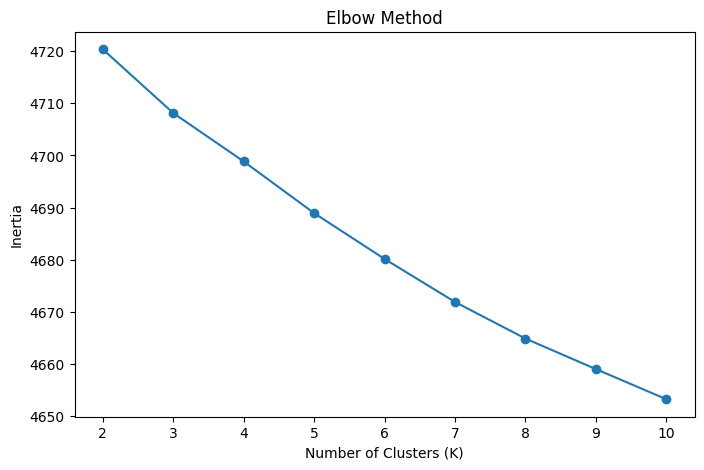

In [284]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [285]:
from sklearn.cluster import KMeans

In [286]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

In [287]:
clusters = kmeans.fit_predict(vectors)

In [288]:
movies["cluster"] = clusters

In [289]:
movies["cluster"].value_counts().sort_index()

cluster
0     676
1    1959
2     819
3     572
4     777
Name: count, dtype: int64

In [290]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(vectors)

    inertia.append(kmeans.inertia_)

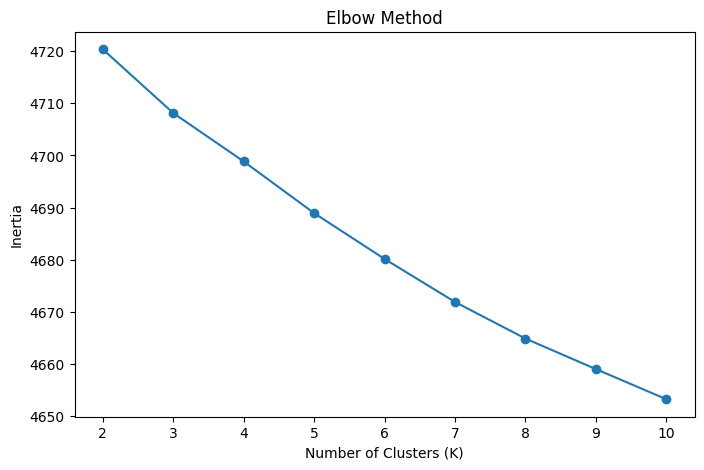

In [291]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [292]:
from sklearn.decomposition import PCA

In [293]:
from sklearn.decomposition import TruncatedSVD

In [294]:
svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

In [295]:
reduced_vectors = svd.fit_transform(vectors)

In [296]:
reduced_vectors.shape

(4803, 2)

In [297]:
movies["component_1"] = reduced_vectors[:, 0]
movies["component_2"] = reduced_vectors[:, 1]

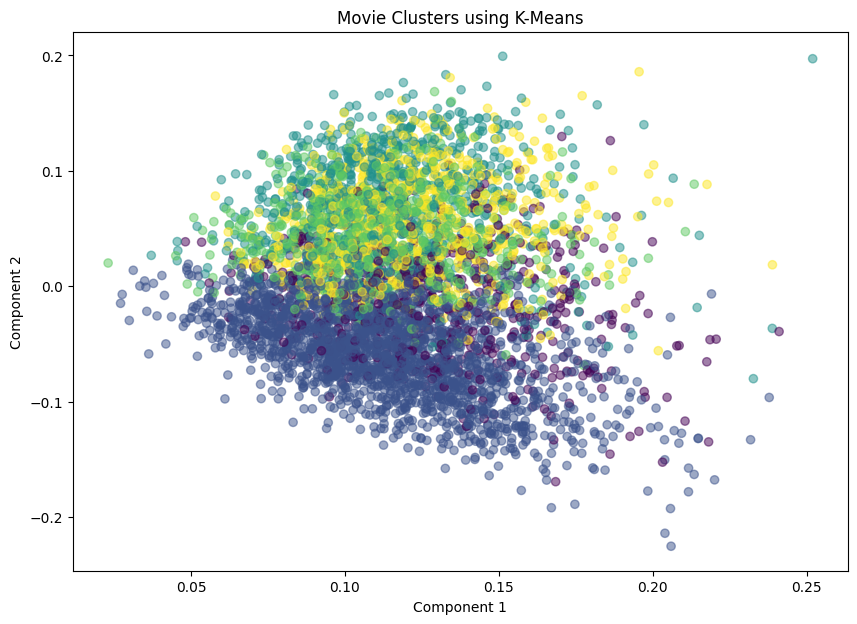

In [298]:
plt.figure(figsize=(10, 7))

plt.scatter(
    movies["component_1"],
    movies["component_2"],
    c=movies["cluster"],
    alpha=0.5
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Movie Clusters using K-Means")

plt.show()

In [299]:
movies[movies["cluster"] == 1][
    ["title", "cluster"]
].head(15)

,title,cluster
25,Titanic,1
49,The Great Gatsby,1
100,The Curious Case of Benjamin Button,1
214,The Perfect Storm,1
226,How Do You Know,1
250,The Aviator,1
251,Gulliver's Travels,1
264,Ali,1
272,Town & Country,1
284,Little Fockers,1


In [300]:
movies["cluster"].value_counts().sort_index()

cluster
0     676
1    1959
2     819
3     572
4     777
Name: count, dtype: int64

In [301]:
from collections import Counter

In [302]:
for cluster_id in sorted(movies["cluster"].unique()):
    cluster_movies = movies[movies["cluster"] == cluster_id]

    words = " ".join(cluster_movies["tags"]).split()

    common_words = Counter(words).most_common(10)

    print(f"\nCluster {cluster_id}")
    print(common_words)


Cluster 0
[('the', 2089), ('a', 1342), ('to', 1275), ('and', 1201), ('of', 981), ('family', 640), ('his', 640), ('in', 559), ('is', 471), ('comedy', 381)]

Cluster 1
[('the', 4523), ('a', 3747), ('and', 3105), ('to', 3067), ('of', 2660), ('in', 1727), ('his', 1669), ('is', 1361), ('drama', 1302), ('her', 1135)]

Cluster 2
[('the', 2808), ('a', 1571), ('to', 1450), ('of', 1355), ('and', 1180), ('in', 734), ('is', 576), ('action', 559), ('his', 545), ('adventure', 371)]

Cluster 3
[('the', 1402), ('a', 1134), ('to', 856), ('of', 830), ('and', 683), ('horror', 510), ('in', 409), ('thriller', 368), ('is', 342), ('his', 304)]

Cluster 4
[('the', 1873), ('a', 1546), ('to', 1201), ('and', 1098), ('of', 1021), ('his', 725), ('crime', 667), ('in', 629), ('is', 568), ('thriller', 479)]


In [303]:
with open("../models/kmeans.pkl", "wb") as file:
    pickle.dump(kmeans, file)

In [304]:
final_k = 5

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(vectors)

movies["cluster"] = clusters

In [305]:
with open("../models/kmeans.pkl", "wb") as file:
    pickle.dump(kmeans, file)

In [306]:
movies.to_csv("../data/processed/processed_movies.csv", index=False)

In [307]:
movies[movies["title"] == "Avengers: Age of Ultron"][
    ["title", "overview", "genres"]
]

,title,overview,genres
7,Avengers: Age of Ultron,When Tony Stark tries to jumpstart a dormant p...,action adventure sciencefiction
